Matplotlib is building the font cache; this may take a moment.


✔ Temiz Veri Başarıyla Yüklendi: 112,650 Satır Kayıt



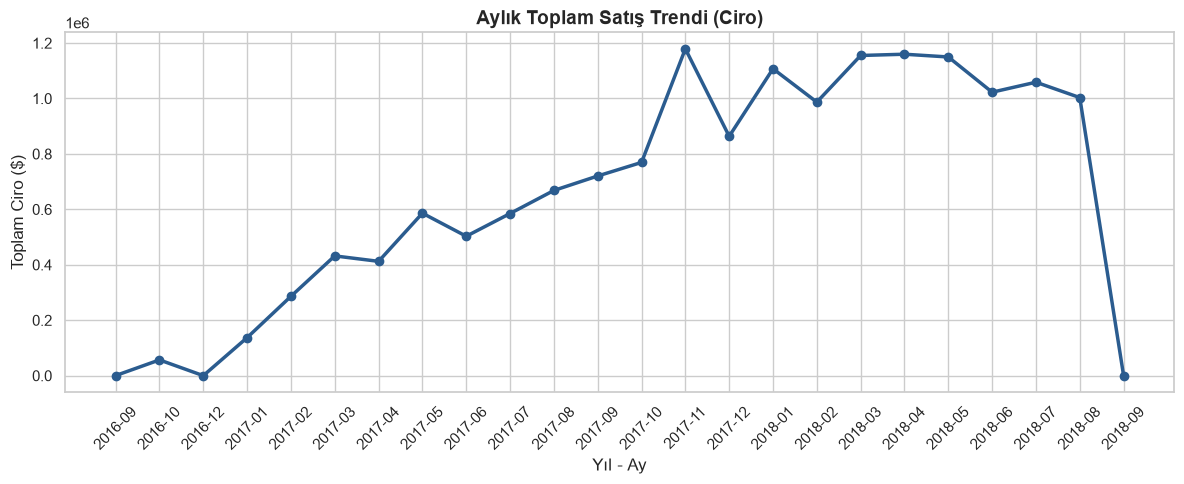

C:\Users\Betül Bağcı\AppData\Local\Temp\ipykernel_15736\1374672069.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


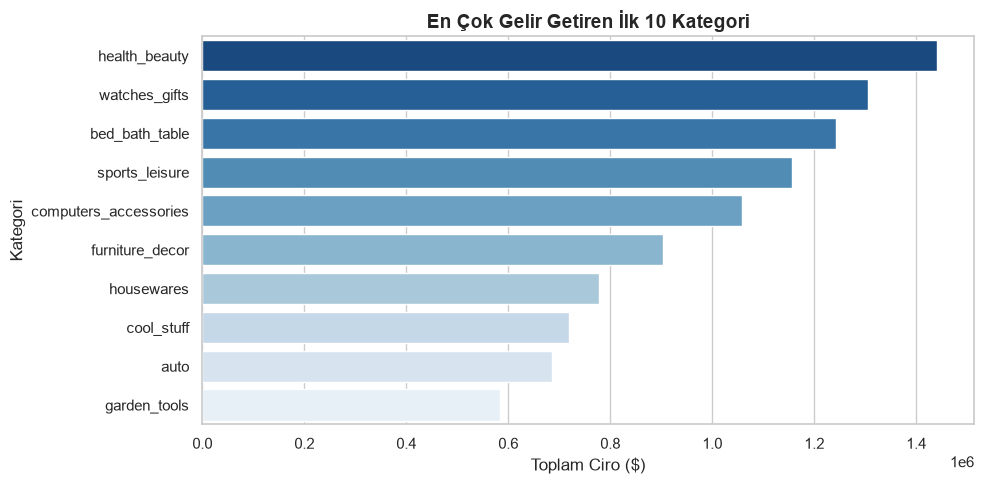

C:\Users\Betül Bağcı\AppData\Local\Temp\ipykernel_15736\1374672069.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


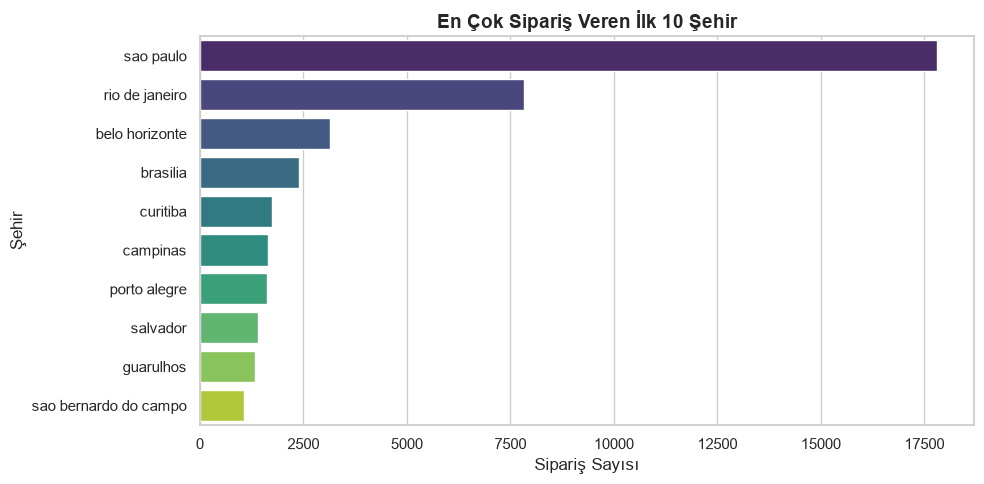

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

# Grafik stil ve boyut ayarları
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Clean veri dizini tespiti
if os.path.exists(os.path.join("Data", "Clean")):
  clean_path = os.path.join("Data", "Clean")
elif os.path.exists(os.path.join("..", "Data", "Clean")):
  clean_path = os.path.join("..", "Data", "Clean")
else:
  clean_path = os.path.join("..", "..", "Data", "Clean")

# Temizlenmiş master veriyi okuyoruz
df = pd.read_csv(os.path.join(clean_path, "master_orders_clean.csv"))
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

print(f"✔ Temiz Veri Başarıyla Yüklendi: {len(df):,} Satır Kayıt\n")

# AYLIK SATIŞ TRENDİ (CİRO) 
df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M")
monthly_sales = (
    df.groupby("year_month")["total_price"].sum().reset_index()
)
monthly_sales["year_month"] = monthly_sales["year_month"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales["year_month"],
    monthly_sales["total_price"],
    marker="o",
    color="#2b5c8f",
    linewidth=2.5,
)
plt.title("Aylık Toplam Satış Trendi (Ciro)", fontsize=14, fontweight="bold")
plt.xlabel("Yıl - Ay", fontsize=12)
plt.ylabel("Toplam Ciro ($)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  EN ÇOK GELİR GETİREN İLK 10 KATEGORİ 
top_categories = (
    df.groupby("category_name")["total_price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_categories, x="total_price", y="category_name", palette="Blues_r"
)
plt.title("En Çok Gelir Getiren İlk 10 Kategori", fontsize=14, fontweight="bold")
plt.xlabel("Toplam Ciro ($)", fontsize=12)
plt.ylabel("Kategori", fontsize=12)
plt.tight_layout()
plt.show()

#  EN ÇOK MÜŞTERİ BULUNAN İLK 10 ŞEHİR 
top_cities = (
    df["customer_city"].value_counts().head(10).reset_index()
)
top_cities.columns = ["city", "customer_count"]

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_cities, x="customer_count", y="city", palette="viridis"
)
plt.title(
    "En Çok Sipariş Veren İlk 10 Şehir", fontsize=14, fontweight="bold"
)
plt.xlabel("Sipariş Sayısı", fontsize=12)
plt.ylabel("Şehir", fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\Betül Bağcı\AppData\Local\Temp\ipykernel_15736\263502518.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_counts, x="count", y="payment_type", palette="mako")


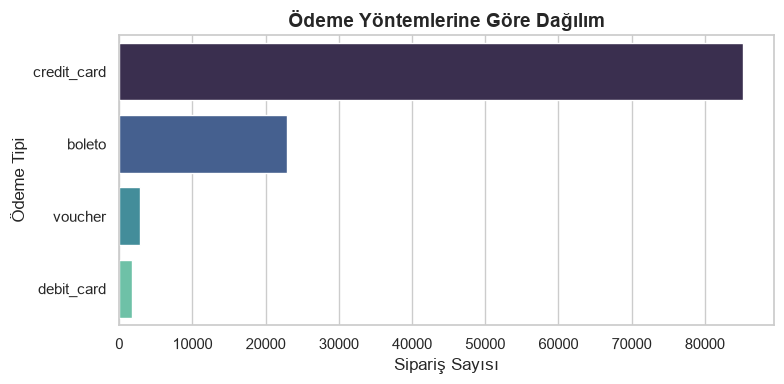

 Sipariş Durumları Dağılımı 
order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64


In [3]:
# ÖDEME YÖNTEMLERİ DAĞILIMI 
plt.figure(figsize=(8, 4))
payment_counts = df["payment_type"].value_counts().reset_index()
payment_counts.columns = ["payment_type", "count"]

sns.barplot(data=payment_counts, x="count", y="payment_type", palette="mako")
plt.title("Ödeme Yöntemlerine Göre Dağılım", fontsize=14, fontweight="bold")
plt.xlabel("Sipariş Sayısı", fontsize=12)
plt.ylabel("Ödeme Tipi", fontsize=12)
plt.tight_layout()
plt.show()

# SİPARİŞ DURUMU (Tamamlanan / İptal / İade) 
print(" Sipariş Durumları Dağılımı ")
print(df["order_status"].value_counts())